In [17]:
import os
import sys
from pathlib import Path
import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt
TDDFA_ROOT = Path.cwd() / "3DDFA_V2"
sys.path.insert(0, str(TDDFA_ROOT))
from FaceBoxes import FaceBoxes
from TDDFA import TDDFA

In [18]:
def read_image_rgb(path):
    
    bgr = cv2.imread(path)

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgb = rgb.astype(np.float32)/255.0
    return rgb

In [19]:
def gaussian_blur(image, sigma):

    kernel_size = int(2 * round(3 * sigma) + 1)

    blurred = cv2.GaussianBlur(image,ksize=(kernel_size,kernel_size),sigmaX=sigma,sigmaY=sigma,)

    return blurred

In [20]:
EPS = 1e-6

def single_scale_retinex(image, sigma):

    illumination = gaussian_blur(image, sigma)
    texture_log = np.log(np.maximum(EPS, image)) - np.log(np.maximum(EPS, illumination))
    return texture_log

In [21]:
def multi_scale_retinex(image, sigmas=(15, 80, 250)):
    outputs = []

    for sigma in sigmas:
        texture_log = single_scale_retinex(image, sigma)
        outputs.append(texture_log)

    tmsr = np.mean(outputs, axis=0)

    return tmsr

In [31]:
def run_3ddfa_reconstruction(
    image_bgr,
    tddfa_root=TDDFA_ROOT,
    gpu_mode=False,
    dense_flag=True,
):
    tddfa_root = Path(tddfa_root)

    cfg_path = tddfa_root / "configs" / "mb1_120x120.yml"

    with open(cfg_path, "r") as f:
        cfg = yaml.safe_load(f)

    old_cwd = os.getcwd()
    os.chdir(tddfa_root)

    try:
        face_boxes = FaceBoxes()
        boxes = face_boxes(image_bgr)

        if len(boxes) == 0:
            raise RuntimeError("No face detected by FaceBoxes.")

        boxes = sorted(
            boxes,
            key=lambda b: float((b[2] - b[0]) * (b[3] - b[1])),
            reverse=True,
        )
        boxes = [boxes[0]]

        tddfa = TDDFA(gpu_mode=gpu_mode, **cfg)

        param_lst, roi_box_lst = tddfa(image_bgr, boxes)

        ver_lst = tddfa.recon_vers(
            param_lst,
            roi_box_lst,
            dense_flag=dense_flag,
        )

    finally:
        os.chdir(old_cwd)

    # ver_lst[0] is [3, N_vertices], so transpose this one.
    vertices = ver_lst[0].T.astype(np.float32)

    # IMPORTANT:
    # In 3DDFA_V2, tddfa.tri is already [N_triangles, 3].
    # Do NOT transpose it.
    triangles = tddfa.tri.astype(np.int32)

    # Safety check in case a different 3DDFA version gives [3, N].
    if triangles.shape[0] == 3 and triangles.shape[1] != 3:
        triangles = triangles.T.astype(np.int32)

    # Safety: convert 1-based indexing to 0-based indexing if needed.
    if triangles.min() == 1:
        triangles = triangles - 1

    print("vertices shape:", vertices.shape)
    print("triangles shape:", triangles.shape)

    return {
        "vertices": vertices,
        "triangles": triangles,
        "boxes": boxes,
        "param_lst": param_lst,
        "roi_box_lst": roi_box_lst,
        "tddfa": tddfa,
        "image_shape": image_bgr.shape,
    }

In [32]:
def compute_vertex_normals(vertices, triangles):
    """
    Compute smooth normal at each mesh vertex.

    vertices:
        [N_vertices, 3]

    triangles:
        [N_triangles, 3]
    """

    v0 = vertices[triangles[:, 0]]
    v1 = vertices[triangles[:, 1]]
    v2 = vertices[triangles[:, 2]]

    face_normals = np.cross(v1 - v0, v2 - v0)

    vertex_normals = np.zeros_like(vertices, dtype=np.float32)

    for k in range(3):
        np.add.at(vertex_normals, triangles[:, k], face_normals)

    lengths = np.linalg.norm(vertex_normals, axis=1, keepdims=True)
    vertex_normals = vertex_normals / np.maximum(lengths, 1e-8)

    return vertex_normals.astype(np.float32)

In [33]:
def rasterize_normal_map(
    vertices,
    triangles,
    vertex_normals,
    image_shape,
    tddfa_root=TDDFA_ROOT,
):
    """
    Convert mesh vertex normals into image-space normal map.

    Returns:
        normal_map [H, W, 3]
        face_mask  [H, W]
    """

    tddfa_root = Path(tddfa_root)
    sys.path.insert(0, str(tddfa_root))

    from Sim3DR import rasterize

    H, W = image_shape[:2]

    # Sim3DR Cython requires C-contiguous arrays with exact dtypes.
    vertices = np.ascontiguousarray(vertices, dtype=np.float32)
    triangles = np.ascontiguousarray(triangles, dtype=np.int32)
    vertex_normals = np.ascontiguousarray(vertex_normals, dtype=np.float32)

    try:
        normal_map = rasterize(
            vertices,
            triangles,
            vertex_normals,
            height=H,
            width=W,
            channel=3,
        )
    except TypeError:
        normal_map = rasterize(
            vertices,
            triangles,
            vertex_normals,
            H,
            W,
            3,
        )

    normal_map = np.ascontiguousarray(normal_map, dtype=np.float32)

    face_mask = np.linalg.norm(normal_map, axis=-1) > 1e-4

    lengths = np.linalg.norm(normal_map, axis=-1, keepdims=True)
    normal_map = normal_map / np.maximum(lengths, 1e-8)

    normal_map[~face_mask] = 0.0

    return normal_map, face_mask

In [34]:
def get_3ddfa_normal_map(image_bgr, tddfa_root=TDDFA_ROOT):
    """
    One function that does:
      image -> 3DDFA mesh -> vertex normals -> normal map
    """

    recon = run_3ddfa_reconstruction(
        image_bgr=image_bgr,
        tddfa_root=tddfa_root,
        gpu_mode=False,
        dense_flag=True,
    )

    vertices = recon["vertices"]
    triangles = recon["triangles"]

    vertex_normals = compute_vertex_normals(
        vertices,
        triangles,
    )

    normal_map, face_mask = rasterize_normal_map(
        vertices=vertices,
        triangles=triangles,
        vertex_normals=vertex_normals,
        image_shape=recon["image_shape"],
        tddfa_root=tddfa_root,
    )

    return {
        "normal_map": normal_map,
        "face_mask": face_mask,
        "vertices": vertices,
        "triangles": triangles,
        "vertex_normals": vertex_normals,
        "boxes": recon["boxes"],
    }

In [35]:
# Spherical harmonic constants for real SH basis up to order 2.
# These are standard constants used in diffuse lighting approximation.
SH_C0 = 0.282095
SH_C1 = 0.488603
SH_C2 = 1.092548
SH_C3 = 0.315392
SH_C4 = 0.546274


def spherical_harmonic_basis_9(normals):
    """
    Compute first 9 real spherical harmonic basis functions.

    Args:
        normals:
            array with shape [N, 3]
            each row is [nx, ny, nz]

    Returns:
        H:
            array with shape [N, 9]
            each row is [h1, h2, ..., h9]
    """

    normals = normals.astype(np.float32)

    # Make sure normals are unit length.
    lengths = np.linalg.norm(normals, axis=1, keepdims=True)
    normals = normals / np.maximum(lengths, 1e-8)

    nx = normals[:, 0]
    ny = normals[:, 1]
    nz = normals[:, 2]

    H = np.column_stack([
        SH_C0 * np.ones_like(nx),          # h1: constant ambient term

        SH_C1 * ny,                        # h2
        SH_C1 * nz,                        # h3
        SH_C1 * nx,                        # h4

        SH_C2 * nx * ny,                   # h5
        SH_C2 * ny * nz,                   # h6
        SH_C3 * (3.0 * nz**2 - 1.0),       # h7
        SH_C2 * nx * nz,                   # h8
        SH_C4 * (nx**2 - ny**2),           # h9
    ])

    return H.astype(np.float32)

In [36]:
def fit_spherical_harmonic_lighting(image_float, tmsr, face_mask, H_basis,):
    ys, xs = np.where(face_mask)

    image_pixels = image_float[ys, xs]       # [N, 3]
    texture_log_pixels = tmsr[ys, xs]        # [N, 3]

    # Retinex gives log texture, so convert to linear.
    texture_pixels = np.exp(texture_log_pixels)

    target = image_pixels / np.maximum(texture_pixels, 1e-6)   # [N, 3]

    gamma = np.zeros((9, 3), dtype=np.float32)

    # Solve one least-squares problem per color channel.
    for c in range(3):
        gamma[:, c], *_ = np.linalg.lstsq(
            H_basis,
            target[:, c],
            rcond=None,
        )

    return gamma, texture_pixels, image_pixels

In [37]:
def extract_specular_from_fitted_lighting(
    image_float,
    face_mask,
    H_basis,
    gamma,
    texture_pixels,
):

    ys, xs = np.where(face_mask)

    image_pixels = image_float[ys, xs]

    # Smooth illumination estimate:
    # [N, 9] @ [9, 3] -> [N, 3]
    illumination_pixels = H_basis @ gamma

    # Non-specular reconstruction:
    # (Hγ) · T
    diffuse_pixels = illumination_pixels * texture_pixels

    # Eq. 12:
    # SPR = (I - (Hγ)T) / T
    specular_pixels = (image_pixels - diffuse_pixels) / np.maximum(texture_pixels, 1e-6)

    # Ambient is only the first SH term h1γ1.
    ambient_illumination = H_basis[:, 0:1] @ gamma[0:1, :]
    ambient_pixels = ambient_illumination * texture_pixels

    # Direct is the remaining SH terms h2...h9.
    direct_illumination = H_basis[:, 1:] @ gamma[1:, :]
    direct_pixels = direct_illumination * texture_pixels

    # Positive part is easier to interpret visually as highlights.
    specular_positive_pixels = np.maximum(specular_pixels, 0.0)

    # Final reconstruction adds positive specular back.
    final_pixels = diffuse_pixels + specular_positive_pixels * texture_pixels
    final_pixels = np.clip(final_pixels, 0.0, 1.0)

    H_img, W_img = face_mask.shape

    def scatter(pixel_values, fill=0.0):
        canvas = np.full((H_img, W_img, 3), fill, dtype=np.float32)
        canvas[ys, xs] = pixel_values
        return canvas

    return {
        "illumination_pixels": illumination_pixels,
        "diffuse_pixels": diffuse_pixels,
        "specular_pixels": specular_pixels,
        "ambient_pixels": ambient_pixels,
        "direct_pixels": direct_pixels,

        "illumination_image": scatter(illumination_pixels),
        "diffuse_image": scatter(diffuse_pixels),
        "specular_image": scatter(specular_pixels),
        "specular_positive_image": scatter(specular_positive_pixels),
        "ambient_image": scatter(ambient_pixels),
        "direct_image": scatter(direct_pixels),
        "final_reconstruction": scatter(final_pixels),
    }

Notebook folder: C:\Users\Krishna Nohwal\Desktop\notebooks
Image path: C:\Users\Krishna Nohwal\Desktop\notebooks\images.jpg
3DDFA path: C:\Users\Krishna Nohwal\Desktop\notebooks\3DDFA_V2
OK file: images.jpg
OK file: mb1_120x120.yml
OK file: bfm_noneck_v3.pkl
OK file: mb1_120x120.pth
OK function: read_image_rgb
OK function: multi_scale_retinex
OK function: get_3ddfa_normal_map
OK function: spherical_harmonic_basis_9
OK function: fit_spherical_harmonic_lighting
Image: (207, 244, 3) float32
TMSR: (207, 244, 3) float32 min/max: -13.681841850280762 0.36769774556159973
vertices shape: (38365, 3)
triangles shape: (76073, 3)
Normal map: (207, 244, 3)
Face pixels: 8761
Normal length mean: 1.0
Normal length min/max: 0.9999998807907104 1.0000001192092896
H_basis: (8761, 9)
gamma: (9, 3)
[[ 2.512434    1.7807652   0.45934895]
 [ 0.42643523  0.64270437  1.1314448 ]
 [ 0.27572218  0.5527667   1.2399694 ]
 [ 0.2894917   0.60979396  1.3642927 ]
 [-0.1103668  -0.19262218 -0.37410635]
 [-0.08055818 -0.1

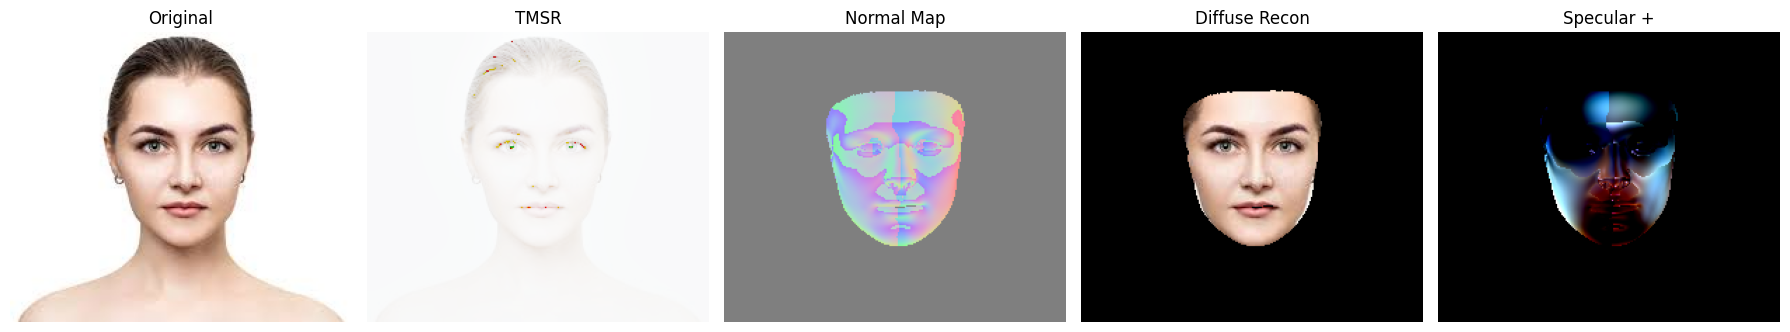

SANITY CHECK PASSED


In [39]:
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ----------------------------
# Sanity-check config
# ----------------------------

IMAGE_PATH = Path.cwd() / "images.jpg"
TDDFA_ROOT = Path.cwd() / "3DDFA_V2"

print("Notebook folder:", Path.cwd())
print("Image path:", IMAGE_PATH)
print("3DDFA path:", TDDFA_ROOT)


# ----------------------------
# 1. Check files and functions
# ----------------------------

required_files = [
    IMAGE_PATH,
    TDDFA_ROOT / "configs" / "mb1_120x120.yml",
    TDDFA_ROOT / "configs" / "bfm_noneck_v3.pkl",
    TDDFA_ROOT / "weights" / "mb1_120x120.pth",
]

for fp in required_files:
    assert fp.exists(), f"Missing file: {fp}"
    print("OK file:", fp.name)

required_functions = [
    "read_image_rgb",
    "multi_scale_retinex",
    "get_3ddfa_normal_map",
    "spherical_harmonic_basis_9",
    "fit_spherical_harmonic_lighting",
]

for name in required_functions:
    assert name in globals(), f"Missing function: {name}"
    print("OK function:", name)


# ----------------------------
# 2. Load image
# ----------------------------

image_bgr = cv2.imread(str(IMAGE_PATH))
assert image_bgr is not None, f"cv2 could not read {IMAGE_PATH}"

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
image_float = image_rgb.astype(np.float32) / 255.0

assert image_float.ndim == 3 and image_float.shape[2] == 3
assert np.isfinite(image_float).all()
assert image_float.min() >= 0 and image_float.max() <= 1

print("Image:", image_float.shape, image_float.dtype)


# ----------------------------
# 3. Run Multi-Scale Retinex
# ----------------------------

tmsr = multi_scale_retinex(image_float, sigmas=(15, 80, 250))

assert tmsr.shape == image_float.shape
assert np.isfinite(tmsr).all()

print("TMSR:", tmsr.shape, tmsr.dtype, "min/max:", float(tmsr.min()), float(tmsr.max()))


# ----------------------------
# 4. Run 3DDFA normal extraction
# ----------------------------

normal_result = get_3ddfa_normal_map(
    image_bgr=image_bgr,
    tddfa_root=TDDFA_ROOT,
)

normal_map = normal_result["normal_map"]
face_mask = normal_result["face_mask"]

assert normal_map.shape == image_float.shape
assert face_mask.shape == image_float.shape[:2]
assert face_mask.dtype == bool
assert face_mask.sum() > 100, "Face mask has too few pixels"
assert np.isfinite(normal_map).all()

normal_lengths = np.linalg.norm(normal_map[face_mask], axis=1)

print("Normal map:", normal_map.shape)
print("Face pixels:", int(face_mask.sum()))
print("Normal length mean:", float(normal_lengths.mean()))
print("Normal length min/max:", float(normal_lengths.min()), float(normal_lengths.max()))

assert np.allclose(normal_lengths.mean(), 1.0, atol=0.05), "Normals are not close to unit length"


# ----------------------------
# 5. Build SH basis
# ----------------------------

ys, xs = np.where(face_mask)
normal_pixels = normal_map[ys, xs]

H_basis = spherical_harmonic_basis_9(normal_pixels)

assert H_basis.shape == (face_mask.sum(), 9)
assert np.isfinite(H_basis).all()

print("H_basis:", H_basis.shape)


# ----------------------------
# 6. Fit lighting gamma
# ----------------------------

gamma, texture_pixels, image_pixels = fit_spherical_harmonic_lighting(
    image_float=image_float,
    tmsr=tmsr,
    face_mask=face_mask,
    H_basis=H_basis,
)

assert gamma.shape == (9, 3)
assert texture_pixels.shape == image_pixels.shape
assert image_pixels.shape == (face_mask.sum(), 3)
assert np.isfinite(gamma).all()
assert np.isfinite(texture_pixels).all()
assert np.isfinite(image_pixels).all()

print("gamma:", gamma.shape)
print(gamma)


# ----------------------------
# 7. Quick reconstruction sanity
# ----------------------------

illumination_pixels = H_basis @ gamma
diffuse_pixels = illumination_pixels * texture_pixels
specular_pixels = (image_pixels - diffuse_pixels) / np.maximum(texture_pixels, 1e-6)

assert illumination_pixels.shape == image_pixels.shape
assert diffuse_pixels.shape == image_pixels.shape
assert specular_pixels.shape == image_pixels.shape
assert np.isfinite(specular_pixels).all()

def scatter(pixel_values):
    canvas = np.zeros_like(image_float, dtype=np.float32)
    canvas[ys, xs] = pixel_values
    return canvas

diffuse_image = scatter(diffuse_pixels)
specular_image = scatter(np.maximum(specular_pixels, 0.0))

def norm01(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

def robust_specular_view(x, percentile=99.5):
    x = np.maximum(x, 0.0)
    scale = np.percentile(np.max(x, axis=-1), percentile)
    return np.clip(x / max(scale, 1e-8), 0, 1)

print("Diffuse min/max:", float(diffuse_image.min()), float(diffuse_image.max()))
print("Specular min/max:", float(specular_pixels.min()), float(specular_pixels.max()))


# ----------------------------
# 8. Visual sanity panel
# ----------------------------

plt.figure(figsize=(18, 4))

plt.subplot(1, 5, 1)
plt.imshow(image_float)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(norm01(tmsr))
plt.title("TMSR")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow((normal_map + 1.0) / 2.0)
plt.title("Normal Map")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(np.clip(diffuse_image, 0, 1))
plt.title("Diffuse Recon")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(robust_specular_view(specular_image))
plt.title("Specular +")
plt.axis("off")

plt.tight_layout()
plt.show()

print("SANITY CHECK PASSED")